# Sección 5: Verificación de la aritmética vectorial

> Si el SGNS propio todavía no está guardado (`cache/sgns_best.kv` o `cache/runs/<SGNS_RUN>_W_in.npy`), el notebook corre solo con gensim y GloVe y avisa. Al guardar el SGNS de A basta con volver a ejecutarlo.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import evaluation as EV

# NumPy 2.0 + Accelerate (Apple Silicon) emite avisos espurios de matmul; los resultados son finitos.
np.seterr(all="ignore")

SEED = 42
CACHE = Path("cache"); RESULTS = Path("results"); FIGS = RESULTS / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
pd.options.display.float_format = "{:.4f}".format
pd.options.display.max_colwidth = 140

# Mejor SGNS propio: o bien cache/sgns_best.kv, o el nombre del run guardado por sgns.save_run
# (cache/runs/<SGNS_RUN>_W_in.npy, filas alineadas con cache/vocab.json).
SGNS_RUN = None

/Users/marinesgarcia/Documents/UVG/DL/venv-lab7/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def load_sgns():
    kv = CACHE / "sgns_best.kv"
    if kv.exists():
        return EV.load_kv(kv, name="SGNS")
    if SGNS_RUN and (CACHE / "runs" / f"{SGNS_RUN}_W_in.npy").exists():
        itos = json.load(open(CACHE / "vocab.json"))["itos"]
        return EV.EmbeddingSpace.from_itos(np.load(CACHE / "runs" / f"{SGNS_RUN}_W_in.npy"), itos, name="SGNS")
    print("AVISO: no hay SGNS propio guardado todavía; se continúa solo con gensim y GloVe.")
    return None


gensim_space = EV.load_kv(CACHE / "gensim_w2v.kv", name="gensim")        # generado por gensim_glove.ipynb
glove_space = EV.EmbeddingSpace.from_keyed_vectors(api.load("glove-wiki-gigaword-100"), name="GloVe-100")
sgns_space = load_sgns()

models = {s.name: s for s in [sgns_space, gensim_space, glove_space] if s is not None}
OWN = [n for n in models if n != "GloVe-100"]          # modelos entrenados por nosotros
for n, s in models.items():
    print(f"{n:10s} vocab {len(s):>7,}  dim {s.dim}")

questions = EV.load_analogies()
cats = list(dict.fromkeys(q[0] for q in questions))

# Vocabulario compartido: las 30,000 palabras más frecuentes presentes en TODOS los modelos.
# La frecuencia es la del corpus de WikiText (el vocabulario de gensim/SGNS viene ordenado por frecuencia).
shared = EV.shared_vocabulary(list(models.values()), n=30000, order_by=gensim_space)
shared_models = {n: s.subset(shared, name=n) for n, s in models.items()}
print(f"\nVocabulario compartido: {len(shared):,} palabras (en los {len(models)} modelos)")

AVISO: no hay SGNS propio guardado todavía; se continúa solo con gensim y GloVe.
gensim     vocab 109,644  dim 100
GloVe-100  vocab 400,000  dim 100

Vocabulario compartido: 30,000 palabras (en los 2 modelos)


## 5.1 Analogías individuales

### `analogia(a, b, c, k)`: «a es a b como c es a ?» con 3CosAdd


In [3]:
def analogia(space, a, b, c, k=5, excluir=True):
    """a es a b como c es a ?  Devuelve [(palabra, coseno con el vector resultante)] de las k mejores."""
    U = space.unit                                   # embeddings normalizados (norma L2 = 1)
    ia, ib, ic = (space.word2idx[w] for w in (a, b, c))
    q = U[ib] - U[ia] + U[ic]
    q /= np.linalg.norm(q)
    sims = U @ q                                     # coseno de cada palabra con q
    if excluir:
        sims[[ia, ib, ic]] = -np.inf                 # a, b y c no pueden ser la respuesta
    top = np.argsort(-sims)[:k]
    return [(space.itos[i], float(sims[i])) for i in top]


for n, s in models.items():
    print(n, "->", [(w, round(x, 3)) for w, x in analogia(s, "man", "king", "woman")])

gensim -> [('queen', 0.745), ('consort', 0.677), ('jagiellon', 0.674), ('coronation', 0.674), ('monarch', 0.664)]
GloVe-100 -> [('queen', 0.77), ('monarch', 0.684), ('throne', 0.676), ('daughter', 0.659), ('princess', 0.652)]


In [4]:
rng = np.random.default_rng(SEED)
rows = []
for n, s in models.items():
    kv = s.to_keyed_vectors()
    ok = [q for q in questions if all(w in s for w in q[1:4])]
    sample = [ok[i] for i in rng.choice(len(ok), 300, replace=False)]
    same, max_diff = 0, 0.0
    for _, a, b, c, _d in sample:
        mine = analogia(s, a, b, c, k=5)
        ref = kv.most_similar(positive=[b, c], negative=[a], topn=5)
        same += [w for w, _ in mine] == [w for w, _ in ref]
        max_diff = max(max_diff, max(abs(x[1] - y[1]) for x, y in zip(mine, ref)))
    rows.append(dict(modelo=n, preguntas=len(sample), top5_identico=same / len(sample), dif_max_similitud=max_diff))
pd.DataFrame(rows).set_index("modelo")

,preguntas,top5_identico,dif_max_similitud
modelo,,,
gensim,300,1.0000,0.0000
GloVe-100,300,1.0000,0.0000


### 23 analogías propias de 7 tipos

In [5]:
own = [  # (tipo, a, b, c, esperada)
    ("género", "man", "king", "woman", "queen"),
    ("género", "man", "actor", "woman", "actress"),
    ("género", "boy", "girl", "brother", "sister"),
    ("género", "father", "mother", "son", "daughter"),
    ("país–capital", "france", "paris", "italy", "rome"),
    ("país–capital", "japan", "tokyo", "germany", "berlin"),
    ("país–capital", "spain", "madrid", "russia", "moscow"),
    ("país–gentilicio", "spain", "spanish", "france", "french"),
    ("país–gentilicio", "germany", "german", "italy", "italian"),
    ("país–gentilicio", "china", "chinese", "japan", "japanese"),
    ("comparativo", "good", "better", "bad", "worse"),
    ("comparativo", "big", "bigger", "small", "smaller"),
    ("comparativo", "fast", "faster", "slow", "slower"),
    ("superlativo", "good", "best", "bad", "worst"),
    ("superlativo", "big", "biggest", "small", "smallest"),
    ("superlativo", "tall", "tallest", "short", "shortest"),
    ("tiempo verbal", "go", "went", "see", "saw"),
    ("tiempo verbal", "write", "wrote", "speak", "spoke"),
    ("tiempo verbal", "take", "took", "give", "gave"),
    ("tiempo verbal", "walk", "walked", "play", "played"),
    ("plural", "car", "cars", "child", "children"),
    ("plural", "dog", "dogs", "woman", "women"),
    ("plural", "city", "cities", "country", "countries"),
]


def evaluar_propias(space):
    filas = []
    for tipo, a, b, c, d in own:
        if not all(w in space for w in (a, b, c)):
            filas.append(dict(tipo=tipo, analogía=f"{a}:{b}::{c}:?", esperada=d, top1="(fuera de vocabulario)"))
            continue
        top, rango = EV.analogy(space, a, b, c, k=5, return_rank_of=d)
        assert [w for w, _ in top] == [w for w, _ in analogia(space, a, b, c, k=5)]      # misma función
        q = space.unit[space.word2idx[b]] - space.unit[space.word2idx[a]] + space.unit[space.word2idx[c]]
        cos_d = float(space.unit[space.word2idx[d]] @ (q / np.linalg.norm(q))) if d in space else np.nan
        filas.append(dict(tipo=tipo, analogía=f"{a}:{b}::{c}:?", esperada=d, top1=top[0][0],
                          top5=", ".join(f"{w} ({x:.2f})" for w, x in top), rango=rango, cos_esperada=cos_d))
    return pd.DataFrame(filas)


own_tables = {n: evaluar_propias(s) for n, s in models.items()}
for n, t in own_tables.items():
    print(f"\n===== {n} =====")
    display(t.drop(columns="top1").set_index(["tipo", "analogía"]))


===== gensim =====


esperada  \
tipo            analogía                             
género          man:king::woman:?            queen   
                man:actor::woman:?         actress   
                boy:girl::brother:?         sister   
                father:mother::son:?      daughter   
país–capital    france:paris::italy:?         rome   
                japan:tokyo::germany:?      berlin   
                spain:madrid::russia:?      moscow   
país–gentilicio spain:spanish::france:?     french   
                germany:german::italy:?    italian   
                china:chinese::japan:?    japanese   
comparativo     good:better::bad:?           worse   
                big:bigger::small:?        smaller   
                fast:faster::slow:?         slower   
superlativo     good:best::bad:?             worst   
                big:biggest::small:?      smallest   
                tall:tallest::short:?     shortest   
tiempo verbal   go:went::see:?                 saw   
                write:wrote::speak:?         spoke   
                take:took::give:?             gave   
                walk:walked::play:?         played   
plural          car:cars::child:?         children   
                dog:dogs::woman:?            women   
                city:cities::country:?   countries   

                                                                                                                                   top5  \
tipo            analogía                                                                                                                  
género          man:king::woman:?                     queen (0.74), consort (0.68), jagiellon (0.67), coronation (0.67), monarch (0.66)   
                man:actor::woman:?                         actress (0.86), actors (0.68), actresses (0.67), streep (0.67), swank (0.65)   
                boy:girl::brother:?                    daughter (0.71), son (0.70), half-brothers (0.70), cousin (0.69), husband (0.69)   
                father:mother::son:?                       daughter (0.88), wife (0.81), eldest (0.79), grandchild (0.77), child (0.75)   
país–capital    france:paris::italy:?                  berlin (0.72), vienna (0.70), prague (0.69), robert-houdin (0.68), egitto (0.68)   
                japan:tokyo::germany:?                berlin (0.80), munich (0.77), budapest (0.76), düsseldorf (0.73), helsinki (0.73)   
                spain:madrid::russia:?                       spartak (0.72), moscow (0.70), prague (0.66), helsinki (0.65), cska (0.64)   
país–gentilicio spain:spanish::france:?                  french (0.87), belgian (0.71), dutch (0.68), portuguese (0.67), italian (0.66)   
                germany:german::italy:?                 italian (0.88), french (0.76), italians (0.74), austrian (0.73), cassino (0.70)   
                china:chinese::japan:?                     japanese (0.85), taiwanese (0.68), korean (0.64), hātofuru (0.63), オブ (0.63)   
comparativo     good:better::bad:?                       worse (0.71), bigger (0.65), escapology (0.58), stronger (0.56), stupid (0.55)   
                big:bigger::small:?              larger (0.68), smaller (0.64), large (0.56), proportionately (0.55), comparably (0.52)   
                fast:faster::slow:?                          slower (0.74), slowed (0.66), slowing (0.63), quicker (0.61), rapid (0.58)   
superlativo     good:best::bad:?                 awards (0.70), silversleeve (0.70), grammys (0.69), loudwire (0.68), switchfoot (0.68)   
                big:biggest::small:?                  largest (0.60), large (0.59), sizeable (0.55), ever-growing (0.53), 59,000 (0.52)   
                tall:tallest::short:?     longest (0.60), shortest (0.52), longest-running (0.52), second-longest (0.52), ischia (0.52)   
tiempo verbal   go:went::see:?                                    saw (0.73), came (0.60), looked (0.55), entered (0.54), seemed (0.54)   
                write:wrote::speak:?              


===== GloVe-100 =====


esperada  \
tipo            analogía                             
género          man:king::woman:?            queen   
                man:actor::woman:?         actress   
                boy:girl::brother:?         sister   
                father:mother::son:?      daughter   
país–capital    france:paris::italy:?         rome   
                japan:tokyo::germany:?      berlin   
                spain:madrid::russia:?      moscow   
país–gentilicio spain:spanish::france:?     french   
                germany:german::italy:?    italian   
                china:chinese::japan:?    japanese   
comparativo     good:better::bad:?           worse   
                big:bigger::small:?        smaller   
                fast:faster::slow:?         slower   
superlativo     good:best::bad:?             worst   
                big:biggest::small:?      smallest   
                tall:tallest::short:?     shortest   
tiempo verbal   go:went::see:?                 saw   
                write:wrote::speak:?         spoke   
                take:took::give:?             gave   
                walk:walked::play:?         played   
plural          car:cars::child:?         children   
                dog:dogs::woman:?            women   
                city:cities::country:?   countries   

                                                                                                                           top5  \
tipo            analogía                                                                                                          
género          man:king::woman:?                 queen (0.77), monarch (0.68), throne (0.68), daughter (0.66), princess (0.65)   
                man:actor::woman:?       actress (0.91), comedian (0.69), actresses (0.68), screenwriter (0.66), starred (0.65)   
                boy:girl::brother:?                      daughter (0.89), wife (0.88), father (0.88), cousin (0.87), son (0.86)   
                father:mother::son:?                  daughter (0.95), wife (0.89), sister (0.84), niece (0.82), husband (0.82)   
país–capital    france:paris::italy:?                     rome (0.82), milan (0.74), naples (0.71), venice (0.70), turin (0.70)   
                japan:tokyo::germany:?              frankfurt (0.84), berlin (0.82), munich (0.73), paris (0.71), vienna (0.69)   
                spain:madrid::russia:?                moscow (0.86), kiev (0.74), kremlin (0.67), tehran (0.66), russian (0.66)   
país–gentilicio spain:spanish::france:?             french (0.93), belgian (0.72), italian (0.71), dutch (0.71), british (0.69)   
                germany:german::italy:?       italian (0.96), spanish (0.79), french (0.74), portuguese (0.71), austrian (0.70)   
                china:chinese::japan:?             japanese (0.95), korean (0.75), taiwanese (0.69), tokyo (0.66), asian (0.63)   
comparativo     good:better::bad:?                        worse (0.84), too (0.75), even (0.73), getting (0.73), because (0.73)   
                big:bigger::small:?                       larger (0.89), smaller (0.87), large (0.79), tiny (0.71), size (0.66)   
                fast:faster::slow:?            slower (0.81), slowed (0.73), slowing (0.73), quicker (0.69), accelerated (0.67)   
superlativo     good:best::bad:?                               worst (0.70), movie (0.67), big (0.67), ever (0.66), film (0.64)   
                big:biggest::small:?                   largest (0.87), large (0.77), larger (0.70), smaller (0.69), main (0.67)   
                tall:tallest::short:?                   longest (0.63), first (0.62), major (0.59), third (0.59), second (0.58)   
tiempo verbal   go:went::see:?                                saw (0.86), came (0.81), when (0.79), later (0.79), turned (0.78)   
                write:wrote::speak:?                 spoke (0.83), speaking (0.75), remarked (0.70), told (0.69), spoken (0.69)   
                take:took::give:?                           gave (0.94)

In [6]:
resumen = []
for n, t in own_tables.items():
    r = t["rango"].dropna()
    resumen.append(dict(modelo=n, analogías=len(t), top1=(t.top1 == t.esperada).sum(), top5=(r <= 5).sum(),
                        rango_mediano=r.median(), cos_esperada_medio=t.cos_esperada.mean()))
display(pd.DataFrame(resumen).set_index("modelo"))

# Aciertos top-1 por tipo
por_tipo = pd.DataFrame({n: (t.top1 == t.esperada).groupby(t.tipo).sum() for n, t in own_tables.items()})
por_tipo = por_tipo.loc[list(dict.fromkeys(x[0] for x in own))]
por_tipo["de"] = pd.Series([x[0] for x in own]).value_counts()
por_tipo

,analogías,top1,top5,rango_mediano,cos_esperada_medio
modelo,,,,,
gensim,23,15,19,1.0000,0.7206
GloVe-100,23,17,20,1.0000,0.8243


,gensim,GloVe-100,de
tipo,,,
género,3,3,4
país–capital,1,2,3
país–gentilicio,3,3,3
comparativo,2,2,3
superlativo,0,1,3
tiempo verbal,3,4,4
plural,3,2,3


### Sin excluir las palabras de la consulta

In [7]:
def primer_lugar_sin_exclusion(space):
    filas = []
    for tipo, a, b, c, d in own:
        if not all(w in space for w in (a, b, c)):
            continue
        w1, s1 = analogia(space, a, b, c, k=1, excluir=False)[0]
        rol = "esperada" if w1 == d else "c" if w1 == c else "b" if w1 == b else "a" if w1 == a else "otra"
        filas.append(dict(analogía=f"{a}:{b}::{c}:?", esperada=d, primero=w1, coseno=s1, es=rol))
    return pd.DataFrame(filas)


sin_excl = {n: primer_lugar_sin_exclusion(s) for n, s in models.items()}
display(pd.DataFrame({n: t.es.value_counts() for n, t in sin_excl.items()}).fillna(0).astype(int)
        .reindex(["esperada", "b", "c", "a", "otra"]).fillna(0).astype(int).rename_axis("palabra en primer lugar"))

ej = pd.concat({n: t.set_index("analogía")[["primero", "coseno"]] for n, t in sin_excl.items()}, axis=1)
ej.head(8)

,gensim,GloVe-100
palabra en primer lugar,,
esperada,7,11
b,5,2
c,8,6
a,0,0
otra,3,4


gensim         GloVe-100       
                          primero coseno    primero coseno
analogía                                                  
man:king::woman:?            king 0.7670       king 0.8361
man:actor::woman:?        actress 0.8648    actress 0.9074
boy:girl::brother:?       brother 0.7815    brother 0.9153
father:mother::son:?     daughter 0.8795   daughter 0.9525
france:paris::italy:?       paris 0.8449       rome 0.8190
japan:tokyo::germany:?     berlin 0.8016  frankfurt 0.8426
spain:madrid::russia:?    spartak 0.7213     moscow 0.8552
spain:spanish::france:?    french 0.8744     french 0.9278

In [8]:
# Lo mismo sobre TODO questions-words.txt (vocabulario compartido): accuracy con y sin exclusión de a, b y c.
filas = []
for n, s in shared_models.items():
    con = EV.evaluate_analogies(s, questions, exclude_query=True)
    sin = EV.evaluate_analogies(s, questions, exclude_query=False)
    filas.append(dict(modelo=n, **{"3CosAdd con exclusión": con["add"]["total"], "3CosAdd sin exclusión": sin["add"]["total"],
                                   "3CosMul con exclusión": con["mul"]["total"], "3CosMul sin exclusión": sin["mul"]["total"]}))
sin_exclusion_bench = pd.DataFrame(filas).set_index("modelo")
sin_exclusion_bench

,3CosAdd con exclusión,3CosAdd sin exclusión,3CosMul con exclusión,3CosMul sin exclusión
modelo,,,,
gensim,0.4542,0.0785,0.4263,0.1939
GloVe-100,0.6551,0.3204,0.6377,0.4714


## 5.2 Evaluación sistemática con vocabulario compartido

In [9]:
res = {n: EV.evaluate_analogies(s, questions) for n, s in shared_models.items()}
assert len({r["n_eval"] for r in res.values()}) == 1, "las preguntas evaluadas deben ser las mismas"
n_eval, n_total = next(iter(res.values()))["n_eval"], len(questions)
print(f"Preguntas evaluadas: {n_eval:,} / {n_total:,}  (cobertura {n_eval / n_total:.1%}) — idénticas para los {len(res)} modelos")

base = next(iter(res.values()))["per_category"][["category", "n_total", "n_eval"]].copy()
base["cobertura"] = base.n_eval / base.n_total
tabla = base.set_index("category")
for n, r in res.items():
    pc = r["per_category"].set_index("category")
    tabla[(n, "3CosAdd")] = pc.acc_add
    tabla[(n, "3CosMul")] = pc.acc_mul
tabla.columns = [c if isinstance(c, str) else f"{c[0]} · {c[1]}" for c in tabla.columns]
for kind, label in [("semantic", "semánticas (5 categorías)"), ("syntactic", "sintácticas (9 categorías)"), ("total", "TOTAL")]:
    fila = {"n_total": np.nan, "n_eval": np.nan, "cobertura": np.nan}
    for n, r in res.items():
        fila[f"{n} · 3CosAdd"], fila[f"{n} · 3CosMul"] = r["add"][kind], r["mul"][kind]
    tabla.loc[label] = fila
tabla

Preguntas evaluadas: 11,833 / 19,544  (cobertura 60.5%) — idénticas para los 2 modelos


,n_total,n_eval,cobertura,gensim · 3CosAdd,gensim · 3CosMul,GloVe-100 · 3CosAdd,GloVe-100 · 3CosMul
category,,,,,,,
capital-common-countries,506.0000,380.0000,0.7510,0.6500,0.6000,0.9289,0.9105
capital-world,4524.0000,1046.0000,0.2312,0.4962,0.4465,0.8834,0.8585
currency,866.0000,54.0000,0.0624,0.0185,0.0185,0.0556,0.0556
city-in-state,2467.0000,1750.0000,0.7094,0.2600,0.2434,0.3029,0.2686
family,506.0000,342.0000,0.6759,0.4883,0.4795,0.8801,0.8684
gram1-adjective-to-adverb,992.0000,812.0000,0.8185,0.1453,0.1207,0.2796,0.2783
gram2-opposite,812.0000,272.0000,0.3350,0.1250,0.0735,0.2721,0.2390
gram3-comparative,1332.0000,1332.0000,1.0000,0.5473,0.5263,0.7995,0.7800
gram4-superlative,1122.0000,702.0000,0.6257,0.2707,0.2792,0.6083,0.6125


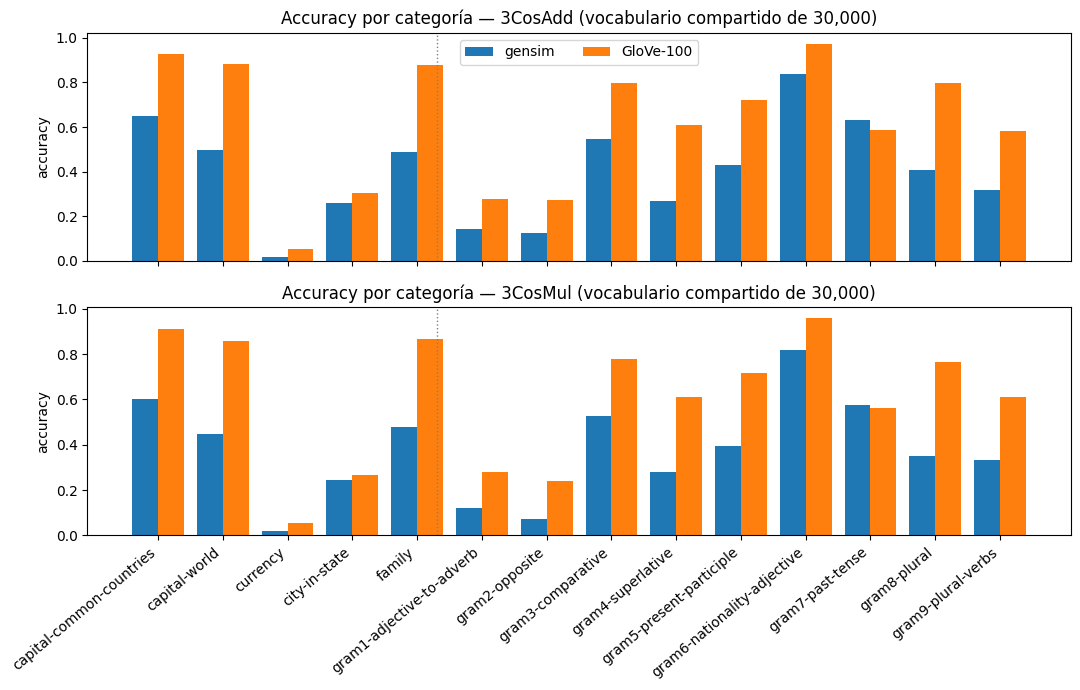

In [10]:
pc = {n: r["per_category"].set_index("category") for n, r in res.items()}
x, bw = np.arange(len(cats)), 0.8 / len(models)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, m, title in zip(axes, ["acc_add", "acc_mul"], ["3CosAdd", "3CosMul"]):
    for i, n in enumerate(models):
        ax.bar(x + i * bw, pc[n].loc[cats, m], bw, label=n)
    ax.set_ylabel("accuracy"); ax.set_title(f"Accuracy por categoría — {title} (vocabulario compartido de {len(shared):,})")
    ax.axvline(4.5, color="gray", ls=":", lw=1)
axes[0].legend(ncol=len(models)); axes[1].set_xticks(x + bw * (len(models) - 1) / 2)
axes[1].set_xticklabels(cats, rotation=40, ha="right"); plt.tight_layout()
plt.savefig(FIGS / "analogias_por_categoria.png", dpi=130); plt.show()

### t-SNE de grupos temáticos (≈500 palabras)

In [11]:
grupos = {
    "países": "france germany italy spain portugal england scotland ireland poland russia china japan india brazil canada australia mexico argentina egypt turkey greece sweden norway denmark finland netherlands belgium switzerland austria hungary romania ukraine iran iraq israel pakistan korea vietnam thailand indonesia philippines cuba peru chile colombia venezuela nigeria kenya ethiopia morocco algeria libya syria lebanon jordan afghanistan nepal bulgaria serbia croatia",
    "capitales": "paris berlin rome madrid lisbon london dublin moscow beijing tokyo delhi cairo athens vienna warsaw budapest prague stockholm oslo copenhagen helsinki brussels amsterdam bern kiev ankara tehran baghdad jerusalem washington ottawa canberra havana lima santiago bogota caracas seoul bangkok hanoi manila jakarta",
    "números": "one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty thirty forty fifty sixty seventy eighty ninety hundred thousand million",
    "animales": "dog cat horse cow pig sheep goat chicken duck bird fish lion tiger bear wolf fox deer rabbit mouse rat monkey elephant giraffe zebra snake lizard frog turtle shark whale dolphin eagle owl hawk crow parrot butterfly bee ant spider mosquito beetle camel donkey bull ox leopard cheetah gorilla squirrel otter",
    "verbos": "run walk jump swim fly eat drink sleep write read speak talk say tell ask answer think know understand learn teach play work build make create destroy break open close begin start stop finish buy sell pay give take bring carry send receive love hate like want need find lose win fight kill die live",
    "colores": "red blue green yellow black white orange purple pink brown gray grey gold silver",
    "meses y días": "january february march april may june july august september october november december monday tuesday wednesday thursday friday saturday sunday",
    "familia": "father mother son daughter brother sister uncle aunt grandfather grandmother husband wife king queen prince princess man woman boy girl child baby",
    "profesiones": "doctor nurse teacher engineer lawyer judge soldier farmer painter writer singer actor actress dancer musician scientist professor priest pilot sailor driver cook baker artist poet director manager president minister mayor senator general captain",
    "cuerpo": "head hand arm leg foot eye ear nose mouth face hair heart finger neck shoulder knee skin blood bone brain tooth lip chest stomach",
    "comida": "bread cheese milk butter egg meat beef pork rice wheat corn potato tomato apple banana grape lemon sugar salt coffee tea wine beer soup cake fruit vegetable",
    "transporte": "car bus train plane ship boat bicycle truck taxi road bridge airport station railway highway harbor",
    "tecnología": "computer software internet technology data program machine network engine robot satellite laser electric digital electronic telephone television radio camera battery",
}
palabra_grupo = {}
for g, ws in grupos.items():
    for w in ws.split():
        palabra_grupo.setdefault(w, g)          # una palabra, un solo grupo
tema_words = [w for w in palabra_grupo if w in set(shared)]
tema_labels = np.array([palabra_grupo[w] for w in tema_words])
print(f"{len(tema_words)} palabras temáticas en el vocabulario compartido (de {len(palabra_grupo)}), en {len(set(tema_labels))} grupos")


def pureza_y_silueta(space, k=5):
    X = space.subset(tema_words).unit
    S = X @ X.T
    np.fill_diagonal(S, -np.inf)
    nn_idx = np.argsort(-S, axis=1)[:, :k]
    pur = (tema_labels[nn_idx] == tema_labels[:, None]).mean(1)
    por_grupo = pd.Series(pur).groupby(tema_labels).mean()
    return pur.mean(), float(silhouette_score(X, tema_labels, metric="cosine")), por_grupo


stats = {n: pureza_y_silueta(s) for n, s in shared_models.items()}
display(pd.DataFrame({n: dict(pureza_vecinos=p, silueta_coseno=sil) for n, (p, sil, _) in stats.items()}).T)
display(pd.DataFrame({n: g for n, (_, _, g) in stats.items()}).rename_axis("grupo"))

408 palabras temáticas en el vocabulario compartido (de 413), en 13 grupos


,pureza_vecinos,silueta_coseno
gensim,0.8569,0.2123
GloVe-100,0.8672,0.2190


,gensim,GloVe-100
grupo,,
animales,0.8082,0.9020
capitales,0.6051,0.7231
colores,0.9286,0.9571
comida,0.8593,0.8593
cuerpo,0.9667,0.8833
familia,0.9455,0.9909
meses y días,1.0000,1.0000
números,0.9867,0.9933
países,0.9400,0.9200


Mejor modelo propio (3CosAdd total, vocabulario compartido): gensim (0.454)  <- aún no hay SGNS propio guardado; se usa gensim


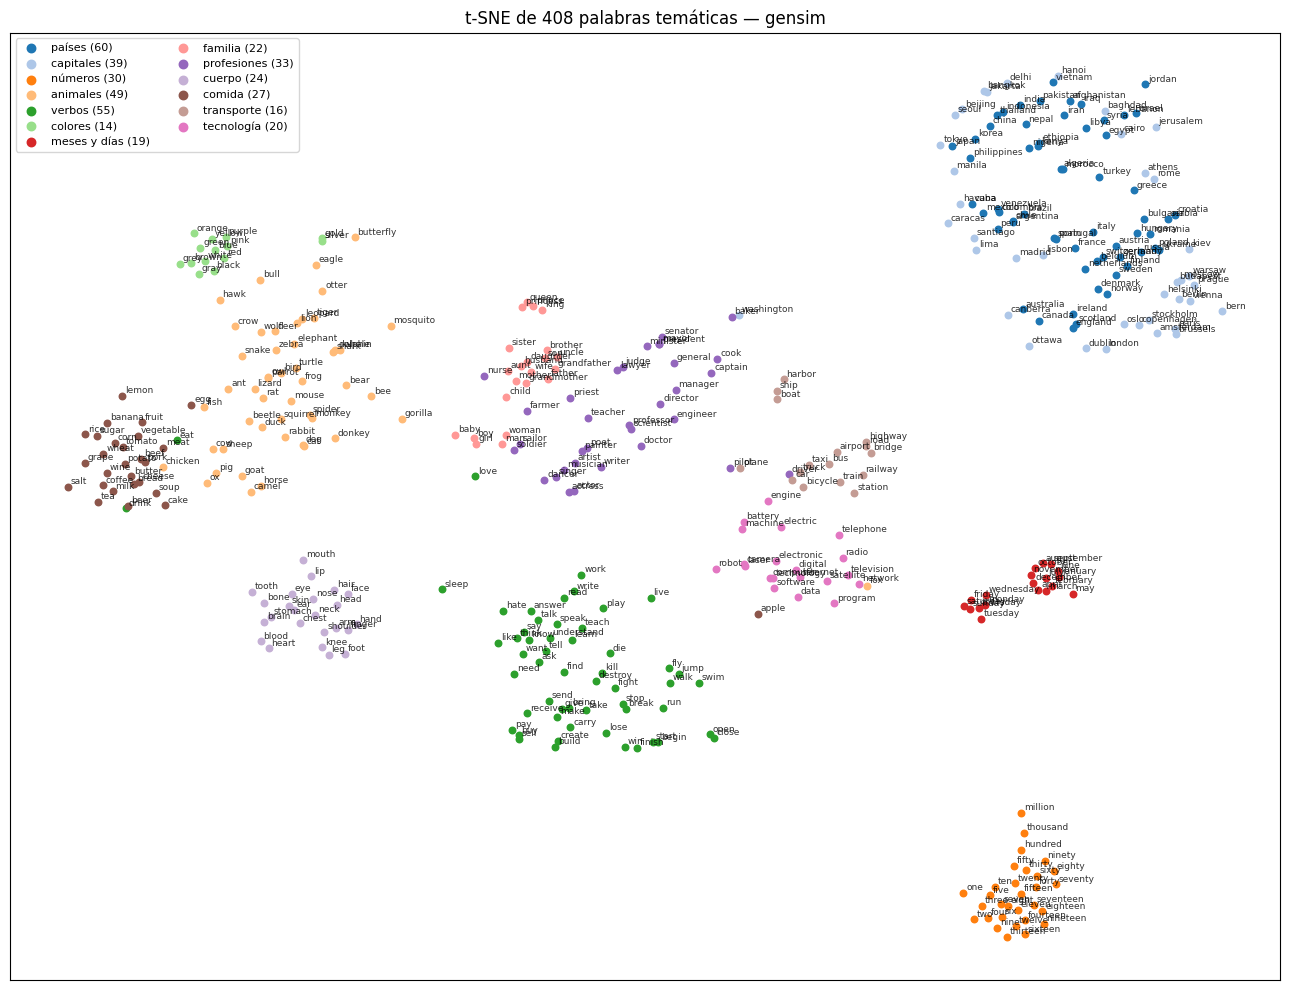

In [12]:
mejor = max(OWN, key=lambda n: res[n]["add"]["total"])
print(f"Mejor modelo propio (3CosAdd total, vocabulario compartido): {mejor} "
      f"({res[mejor]['add']['total']:.3f})" + ("  <- aún no hay SGNS propio guardado; se usa gensim" if mejor == "gensim" and sgns_space is None else ""))

X = shared_models[mejor].subset(tema_words).E
emb2d = TSNE(n_components=2, perplexity=30, init="pca", metric="cosine", random_state=SEED).fit_transform(X)

fig, ax = plt.subplots(figsize=(13, 10))
colores = plt.get_cmap("tab20")
for i, g in enumerate(grupos):
    m = tema_labels == g
    ax.scatter(emb2d[m, 0], emb2d[m, 1], s=22, color=colores(i), label=f"{g} ({m.sum()})")
    for (px, py), w in zip(emb2d[m], np.array(tema_words)[m]):
        ax.annotate(w, (px, py), fontsize=6.5, alpha=0.8, xytext=(2, 2), textcoords="offset points")
ax.legend(loc="best", fontsize=8, ncol=2, markerscale=1.3)
ax.set_title(f"t-SNE de {len(tema_words)} palabras temáticas — {mejor}"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(FIGS / "tsne_mejor_modelo.png", dpi=130); plt.show()

## 5.3 Paralelismo de los vectores diferencia

In [13]:
par = {n: EV.parallelism(s, questions, seed=SEED).set_index("category") for n, s in shared_models.items()}
tabla_par = pd.concat({n: p[["mean_cos_pairs", "random_baseline"]] for n, p in par.items()}, axis=1)
tabla_par.insert(0, "n_parejas", next(iter(par.values())).n_pairs)
medias = pd.DataFrame({n: dict(coseno_promedio=p.mean_cos_pairs.mean(),
                               semánticas=p.loc[[c for c in p.index if EV.is_semantic(c)], "mean_cos_pairs"].mean(),
                               sintácticas=p.loc[[c for c in p.index if not EV.is_semantic(c)], "mean_cos_pairs"].mean(),
                               azar=p.random_baseline.mean()) for n, p in par.items()}).T
display(tabla_par)
display(medias.rename_axis("promedio entre categorías (macro)"))

n_parejas         gensim                  \
                                      mean_cos_pairs random_baseline   
category                                                               
capital-common-countries           20         0.3420         -0.0116   
capital-world                      56         0.2573         -0.0013   
currency                            8         0.2556         -0.0080   
city-in-state                      57         0.2004         -0.0004   
family                             19         0.2647          0.0080   
gram1-adjective-to-adverb          29         0.1285         -0.0003   
gram2-opposite                     17         0.0982          0.0135   
gram3-comparative                  37         0.2954         -0.0049   
gram4-superlative                  27         0.2818         -0.0090   
gram5-present-participle           30         0.1915          0.0040   
gram6-nationality-adjective        37         0.4876         -0.0021   
gram7-past-tense                   37         0.2111          0.0015   
gram8-plural                       32         0.1599         -0.0001   
gram9-plural-verbs                 26         0.2464          0.0028   

                                 GloVe-100                  
                            mean_cos_pairs random_baseline  
category                                                    
capital-common-countries            0.5821          0.0013  
capital-world                       0.5667          0.0018  
currency                            0.2511         -0.0178  
city-in-state                       0.3368         -0.0035  
family                              0.5066          0.0063  
gram1-adjective-to-adverb           0.2708         -0.0007  
gram2-opposite                      0.2311          0.0086  
gram3-comparative                   0.4243         -0.0096  
gram4-superlative                   0.4654         -0.0086  
gram5-present-participle            0.3185         -0.0044  
gram6-nationality-adjective         0.7491          0.0016  
gram7-past-tense                    0.2888          0.0026  
gram8-plural                        0.3139          0.0031  
gram9-plural-verbs                  0.3564          0.0052

,coseno_promedio,semánticas,sintácticas,azar
promedio entre categorías (macro),,,,
gensim,0.2443,0.2640,0.2334,-0.0006
GloVe-100,0.4044,0.4487,0.3798,-0.0010


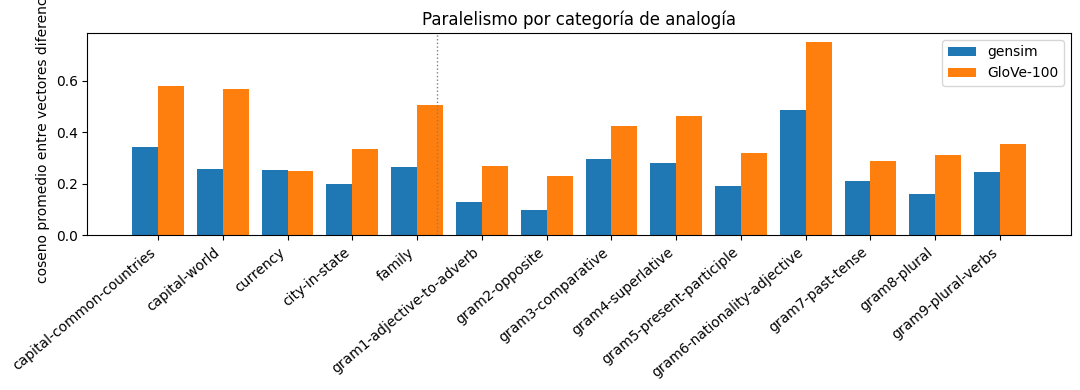

,Spearman entre paralelismo y accuracy (14 categorías)
gensim,0.6484
GloVe-100,0.8813


In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
for i, n in enumerate(models):
    ax.bar(np.arange(len(cats)) + i * bw, par[n].loc[cats, "mean_cos_pairs"], bw, label=n)
ax.axhline(0, color="k", lw=0.6); ax.axvline(4.5, color="gray", ls=":", lw=1)
ax.set_xticks(np.arange(len(cats)) + bw * (len(models) - 1) / 2); ax.set_xticklabels(cats, rotation=40, ha="right")
ax.set_ylabel("coseno promedio entre vectores diferencia"); ax.set_title("Paralelismo por categoría de analogía"); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "paralelismo.png", dpi=130); plt.show()

# ¿Más paralelismo = más accuracy? (por categoría, 3CosAdd)
corr = pd.DataFrame({n: dict(spearman=pd.concat([par[n].mean_cos_pairs, pc[n].acc_add], axis=1).corr(method="spearman").iloc[0, 1])
                     for n in models}).T
corr.rename(columns={"spearman": "Spearman entre paralelismo y accuracy (14 categorías)"})

In [15]:
# Resultados para la tabla de la sección 7 y la discusión (sección 8)
salida = {}
for n in models:
    r = res[n]
    salida[n] = dict(
        vocab=len(models[n]), dim=models[n].dim, vocab_compartido=len(shared),
        preguntas_evaluadas=r["n_eval"], preguntas_total=r["n_total"], cobertura=r["coverage"],
        add=r["add"], mul=r["mul"],
        sin_exclusion=sin_exclusion_bench.loc[n].to_dict(),
        por_categoria=r["per_category"].to_dict(orient="records"),
        paralelismo_medio=float(par[n].mean_cos_pairs.mean()), paralelismo_azar=float(par[n].random_baseline.mean()),
        paralelismo_por_categoria=par[n].reset_index().to_dict(orient="records"),
        tsne_pureza=float(stats[n][0]), tsne_silueta=float(stats[n][1]),
        propias_top1=int((own_tables[n].top1 == own_tables[n].esperada).sum()), propias_total=len(own),
    )
salida["_meta"] = dict(mejor_modelo_propio=mejor, sgns_incluido=sgns_space is not None)
json.dump(salida, open(RESULTS / "aritmetica_vectorial.json", "w"), indent=1, default=float)
print("Guardado en", RESULTS / "aritmetica_vectorial.json")

Guardado en results/aritmetica_vectorial.json
